In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,classification_report
import nltk

In [3]:
df=pd.read_csv("training.1600000.processed.noemoticon.csv",encoding="latin-1",header=None)
df.columns=["target","id","date","query","user","text"]

In [4]:
df.head()


,target,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
df.shape

(1600000, 6)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   target  1600000 non-null  int64
 1   id      1600000 non-null  int64
 2   date    1600000 non-null  str  
 3   query   1600000 non-null  str  
 4   user    1600000 non-null  str  
 5   text    1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 73.2 MB


In [7]:
df.isnull().sum()

target    0
id        0
date      0
query     0
user      0
text      0
dtype: int64

In [8]:
df["target"].value_counts(),df["target"].value_counts(normalize=True)

(target
 0    800000
 4    800000
 Name: count, dtype: int64,
 target
 0    0.5
 4    0.5
 Name: proportion, dtype: float64)

In [9]:
df["target"]=df["target"].map({0:0,4:1})
df["target"].value_counts()

target
0    800000
1    800000
Name: count, dtype: int64

In [10]:
df["char_length"]=df["text"].apply(len)
df["char_length"].describe()

count    1.600000e+06
mean     7.409011e+01
std      3.644114e+01
min      6.000000e+00
25%      4.400000e+01
50%      6.900000e+01
75%      1.040000e+02
max      3.740000e+02
Name: char_length, dtype: float64

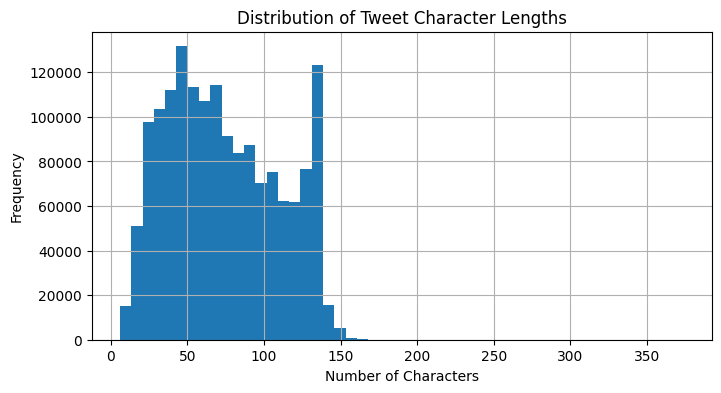

In [11]:
plt.figure(figsize=(8,4))
df["char_length"].hist(bins=50)
plt.title("Distribution of Tweet Character Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()


In [12]:
df_sample=df.groupby("target",group_keys=False).apply(
    lambda x: x.sample(n=100000,random_state=42),
    include_groups=False
)
df_sample.head()

,id,date,query,user,text,char_length
212188,1974671194,Sat May 30 13:36:31 PDT 2009,NO_QUERY,simba98,@xnausikaax oh no! where did u order from? tha...,59
299036,1997882236,Mon Jun 01 17:37:11 PDT 2009,NO_QUERY,Seve76,A great hard training weekend is over. a coup...,121
475978,2177756662,Mon Jun 15 06:39:05 PDT 2009,NO_QUERY,x__claireyy__x,"Right, off to work Only 5 hours to go until I...",56
588988,2216838047,Wed Jun 17 20:02:12 PDT 2009,NO_QUERY,Balasi,I am craving for japanese food,31
138859,1880666283,Fri May 22 02:03:31 PDT 2009,NO_QUERY,djrickdawson,Jean Michel Jarre concert tomorrow gotta work...,65


In [13]:
df_sample["target"]=df.loc[df_sample.index,"target"]

In [14]:
df_sample=df_sample[["target","text"]]
df_sample.head()

,target,text
212188,0,@xnausikaax oh no! where did u order from? tha...
299036,0,A great hard training weekend is over. a coup...
475978,0,"Right, off to work Only 5 hours to go until I..."
588988,0,I am craving for japanese food
138859,0,Jean Michel Jarre concert tomorrow gotta work...


In [15]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  
    text = re.sub(r"@\w+|#\w+", "", text)       
    text = re.sub(r"[^a-z\s]", "", text)      
    text = re.sub(r"\s+", " ", text).strip()    
    return text
df_sample["cleaned_text"] = df_sample["text"].apply(clean_text)

In [16]:
df_sample["cleaned_text"].str.len().describe()

count    200000.000000
mean         61.644095
std          33.944697
min           0.000000
25%          33.000000
50%          57.000000
75%          88.000000
max         159.000000
Name: cleaned_text, dtype: float64

In [17]:
X=df_sample["cleaned_text"]
y=df_sample["target"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [18]:
tfidf=TfidfVectorizer(max_features=10000,ngram_range=(1,2))
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

In [19]:
lr_model=LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf,y_train)
y_pred_lr=lr_model.predict(X_test_tfidf)
print("Logistic Regression Performance")
print("Accuracy: ",accuracy_score(y_test,y_pred_lr))
print("Classification Report")
print(classification_report(y_test,y_pred_lr))


Logistic Regression Performance
Accuracy:  0.792225
Classification Report
              precision    recall  f1-score   support

           0       0.80      0.79      0.79     20000
           1       0.79      0.80      0.79     20000

    accuracy                           0.79     40000
   macro avg       0.79      0.79      0.79     40000
weighted avg       0.79      0.79      0.79     40000



In [20]:
nb_model=MultinomialNB()
nb_model.fit(X_train_tfidf,y_train)
y_pred_nb=nb_model.predict(X_test_tfidf)
print("Multinomial Naive Bayes Performance")
print("Accuracy: ",accuracy_score(y_test,y_pred_nb))
print("Classification Report")
print(classification_report(y_test,y_pred_nb))

Multinomial Naive Bayes Performance
Accuracy:  0.77325
Classification Report
              precision    recall  f1-score   support

           0       0.77      0.79      0.78     20000
           1       0.78      0.76      0.77     20000

    accuracy                           0.77     40000
   macro avg       0.77      0.77      0.77     40000
weighted avg       0.77      0.77      0.77     40000



In [21]:
from sklearn.svm import LinearSVC
svm_model=LinearSVC()
svm_model.fit(X_train_tfidf,y_train)
y_pred_svm=svm_model.predict(X_test_tfidf)
print("SVM Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report")
print(classification_report(y_test,y_pred_svm))


SVM Performance
Accuracy: 0.7889
Classification Report
              precision    recall  f1-score   support

           0       0.80      0.78      0.79     20000
           1       0.78      0.80      0.79     20000

    accuracy                           0.79     40000
   macro avg       0.79      0.79      0.79     40000
weighted avg       0.79      0.79      0.79     40000



In [22]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_tfidf,y_train)
y_pred_rf=rf_model.predict(X_test_tfidf)
print("Random Forest Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report")
print(classification_report(y_test,y_pred_rf))

Random Forest Performance
Accuracy: 0.7177
Classification Report
              precision    recall  f1-score   support

           0       0.74      0.68      0.71     20000
           1       0.70      0.76      0.73     20000

    accuracy                           0.72     40000
   macro avg       0.72      0.72      0.72     40000
weighted avg       0.72      0.72      0.72     40000



In [23]:
df_sample["text_length"]=df_sample["cleaned_text"].str.len()
df_sample["text_length"].describe()

count    200000.000000
mean         61.644095
std          33.944697
min           0.000000
25%          33.000000
50%          57.000000
75%          88.000000
max         159.000000
Name: text_length, dtype: float64

In [24]:
df_sample.groupby("target")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,100000.0,63.66686,34.309582,0.0,35.0,59.0,91.0,159.0
1,100000.0,59.62133,33.453936,0.0,32.0,55.0,85.0,148.0


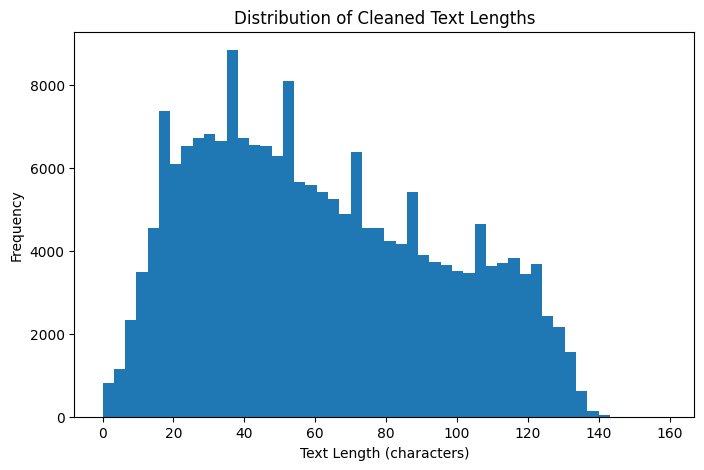

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df_sample["text_length"],bins=50)
plt.xlabel("Text Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Cleaned Text Lengths")
plt.show()


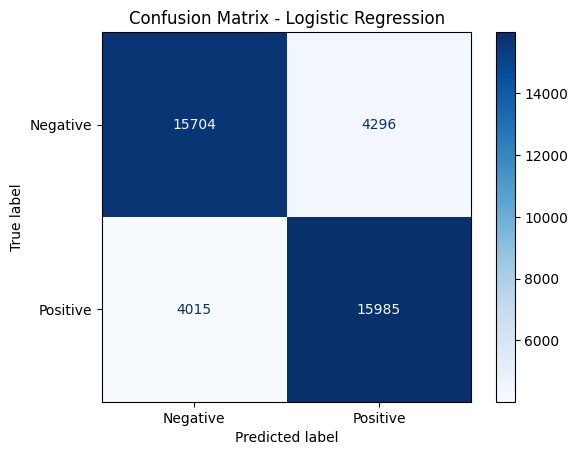

In [26]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm_lr=confusion_matrix(y_test,y_pred_lr)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_lr,display_labels=["Negative","Positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


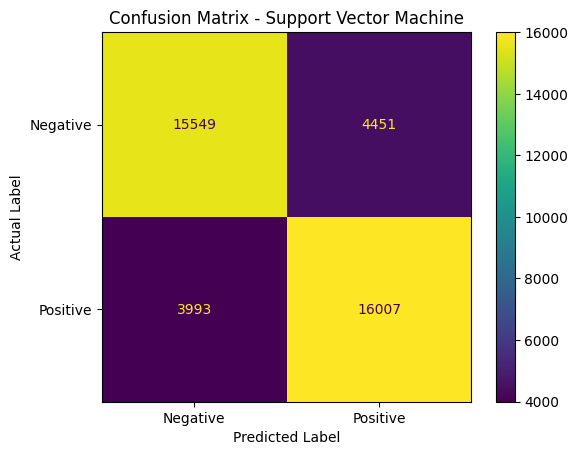

In [27]:
cm_svm=confusion_matrix(y_test,y_pred_svm)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_svm,display_labels=["Negative","Positive"])
disp.plot(cmap="viridis")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Support Vector Machine")
plt.show()

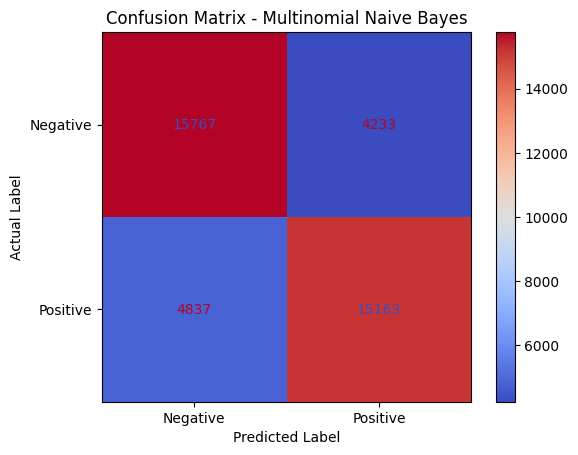

In [28]:
cm_nb=confusion_matrix(y_test,y_pred_nb)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_nb,display_labels=["Negative","Positive"])
disp.plot(cmap="coolwarm")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.show()

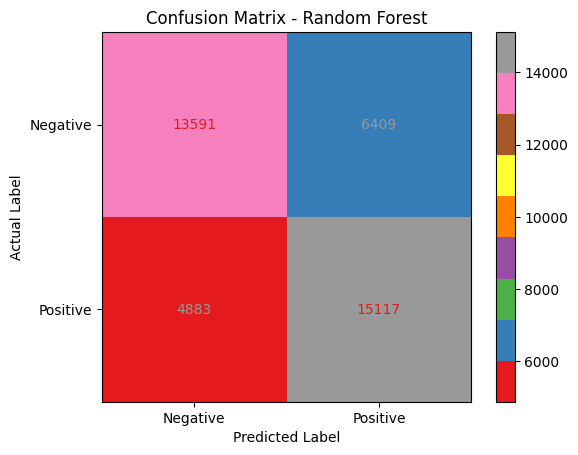

In [29]:
cm_rf=confusion_matrix(y_test,y_pred_rf)
disp=ConfusionMatrixDisplay(confusion_matrix=cm_rf,display_labels=["Negative","Positive"])
disp.plot(cmap="Set1")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [30]:
analysis_df=pd.DataFrame({
    "text":X_test,
    "actual":y_test,
    "predicted":y_pred_lr
})
false_positives=analysis_df[
    (analysis_df['actual']==0) & (analysis_df["predicted"]==1)
]
false_negatives=analysis_df[
    (analysis_df["actual"]==1) & (analysis_df["predicted"]==0)
]
print("Number of False Positives:", len(false_positives))
print("Number of False Negatives:", len(false_negatives))


Number of False Positives: 4296
Number of False Negatives: 4015


In [31]:
false_positives["text"].head(5)

290849                                     so is my lil sis
714241    so tired this iced coffee is so good thoits li...
324983    if its all thats on offer then they are going ...
472959    enjoying a cheese and spring onion sandwich i ...
159768         you just found ooooout imy by the way hahaah
Name: text, dtype: str

In [32]:
false_negatives["text"].head(5)

953239     i have a feeling the nozzles are just too god ...
1059363    yeah we do im just now back to work amp not bu...
1165031                          you didnt know that already
1222496    just hadda hr math exam not cool got another h...
1529665    weekend was good mile hike on saturday notwith...
Name: text, dtype: str

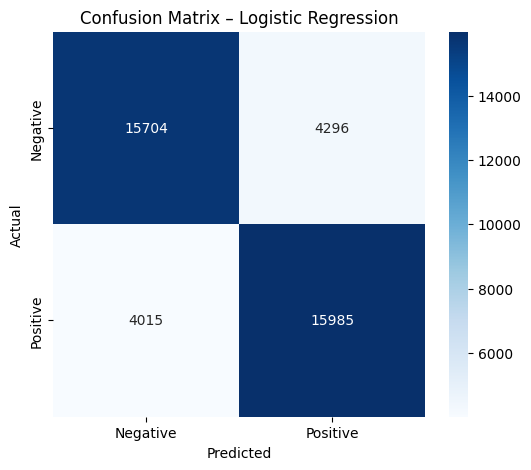

In [33]:
import seaborn as sns
cm=confusion_matrix(y_test,y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

In [34]:
from sklearn.model_selection import cross_val_score,StratifiedKFold
from sklearn.pipeline import Pipeline
pipeline=Pipeline([
    ("tfidf",TfidfVectorizer(max_features=5000)),
    ("clf",LogisticRegression(max_iter=1000))
])
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(
    pipeline,
    df_sample["cleaned_text"],
    df_sample["target"],
    cv=cv,
    scoring="f1"
)
print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1 score:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

Cross-validation F1 scores: [0.78502409 0.78641884 0.7879822  0.786438   0.78716541]
Mean CV F1 score: 0.7866057059897862
Standard Deviation: 0.0009769882013931333


In [35]:
import pickle

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# Save vectorizer
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Model saved successfully!")

Model saved successfully!
